# Pneumonia Detection (Chest X-Ray) — EDA & Model Training

## Dataset Description

**Source:** `chest_xray/` — organized into `train/`, `val/`, and `test/` folders

The dataset contains **chest X-ray images** from pediatric patients (ages 1–5) at Guangzhou Women and Children's Medical Center. Images are categorized into two classes.

### Classes

| Class | Description |
|-------|-------------|
| `NORMAL` | Healthy chest X-ray — clear lungs |
| `PNEUMONIA` | X-ray showing signs of pneumonia (bacterial or viral) |

### Directory Structure

```
chest_xray/
├── train/
│   ├── NORMAL/
│   └── PNEUMONIA/
├── val/
│   ├── NORMAL/
│   └── PNEUMONIA/
└── test/
    ├── NORMAL/
    └── PNEUMONIA/
```

### Key Characteristics
- **Image format:** JPEG, grayscale X-rays (loaded as RGB for pretrained models)
- **Class imbalance:** More pneumonia cases than normal in the training set
- **Approach:** Transfer learning with pretrained CNNs (ResNet-50, EfficientNet-B0)

### Task
Binary image classification — detect pneumonia from chest X-ray images.

---
## 1. Imports & Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve
)
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
%matplotlib inline

# Paths
DATA_DIR = os.path.join('..', 'data', 'chest_xray')
MODELS_DIR = os.path.join('..', 'models')

TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR = os.path.join(DATA_DIR, 'val')
TEST_DIR = os.path.join(DATA_DIR, 'test')

# Hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 15
LEARNING_RATE = 1e-4
PATIENCE = 4          # early stopping patience
FREEZE_EPOCHS = 3    # epochs to keep backbone frozen
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Using device: {DEVICE}')

Using device: cpu


---
## 2. Load & Inspect the Data

In [2]:
# Count images in each split
splits = {'Train': TRAIN_DIR, 'Validation': VAL_DIR, 'Test': TEST_DIR}

for split_name, split_dir in splits.items():
    normal_count = len(os.listdir(os.path.join(split_dir, 'NORMAL')))
    pneumonia_count = len(os.listdir(os.path.join(split_dir, 'PNEUMONIA')))
    total = normal_count + pneumonia_count
    print(f'{split_name:12s} — NORMAL: {normal_count:5d} | PNEUMONIA: {pneumonia_count:5d} | Total: {total:5d}')

Train        — NORMAL:  1341 | PNEUMONIA:  3875 | Total:  5216
Validation   — NORMAL:     8 | PNEUMONIA:     8 | Total:    16
Test         — NORMAL:   234 | PNEUMONIA:   390 | Total:   624


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Class Distribution Across Splits

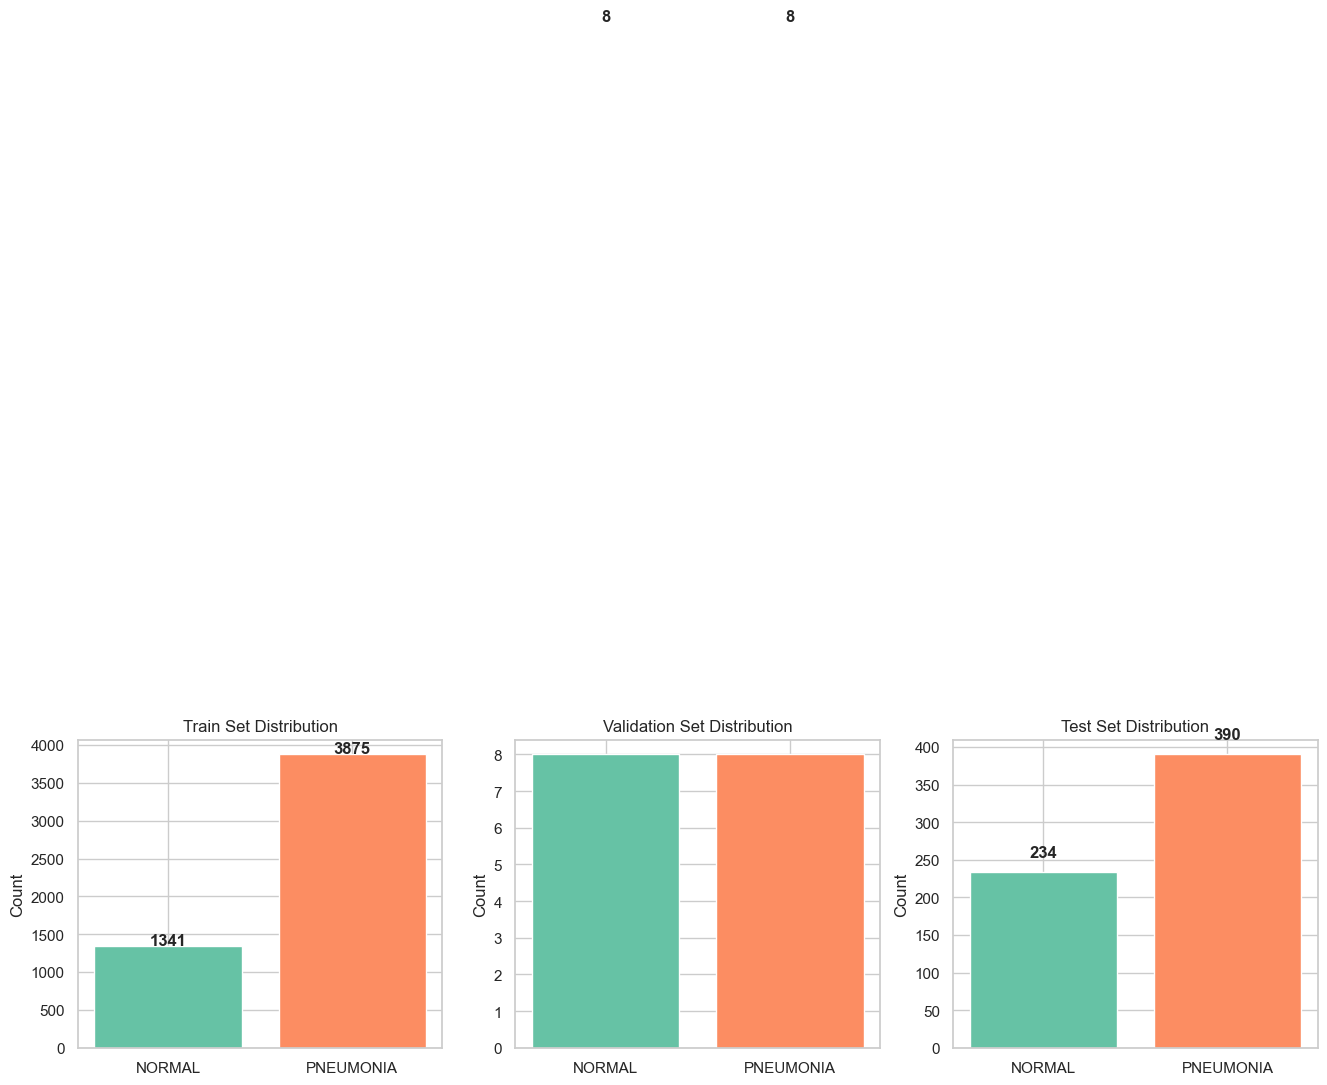

In [3]:
split_data = []
for split_name, split_dir in splits.items():
    for cls in ['NORMAL', 'PNEUMONIA']:
        count = len(os.listdir(os.path.join(split_dir, cls)))
        split_data.append({'Split': split_name, 'Class': cls, 'Count': count})

import pandas as pd
df_splits = pd.DataFrame(split_data)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, (split_name, split_dir) in enumerate(splits.items()):
    subset = df_splits[df_splits['Split'] == split_name]
    colors = ['#66c2a5', '#fc8d62']
    axes[i].bar(subset['Class'], subset['Count'], color=colors)
    axes[i].set_title(f'{split_name} Set Distribution')
    axes[i].set_ylabel('Count')
    for j, row in enumerate(subset.itertuples()):
        axes[i].text(j, row.Count + 20, str(row.Count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

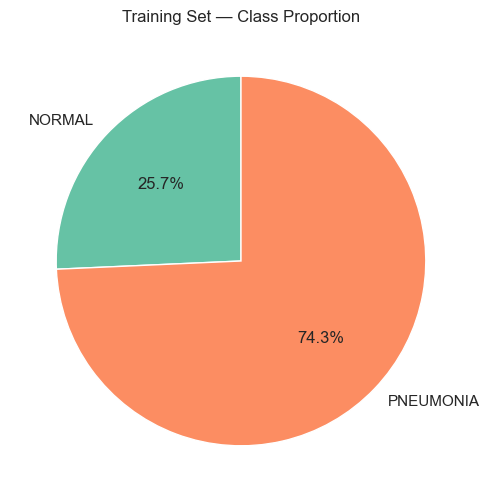

Imbalance ratio (Pneumonia/Normal): 2.89


In [4]:
# Training set pie chart
train_normal = len(os.listdir(os.path.join(TRAIN_DIR, 'NORMAL')))
train_pneumonia = len(os.listdir(os.path.join(TRAIN_DIR, 'PNEUMONIA')))

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie([train_normal, train_pneumonia], labels=['NORMAL', 'PNEUMONIA'],
       autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'], startangle=90)
ax.set_title('Training Set — Class Proportion')
plt.show()

print(f'Imbalance ratio (Pneumonia/Normal): {train_pneumonia/train_normal:.2f}')

### 3.2 Sample X-Ray Images

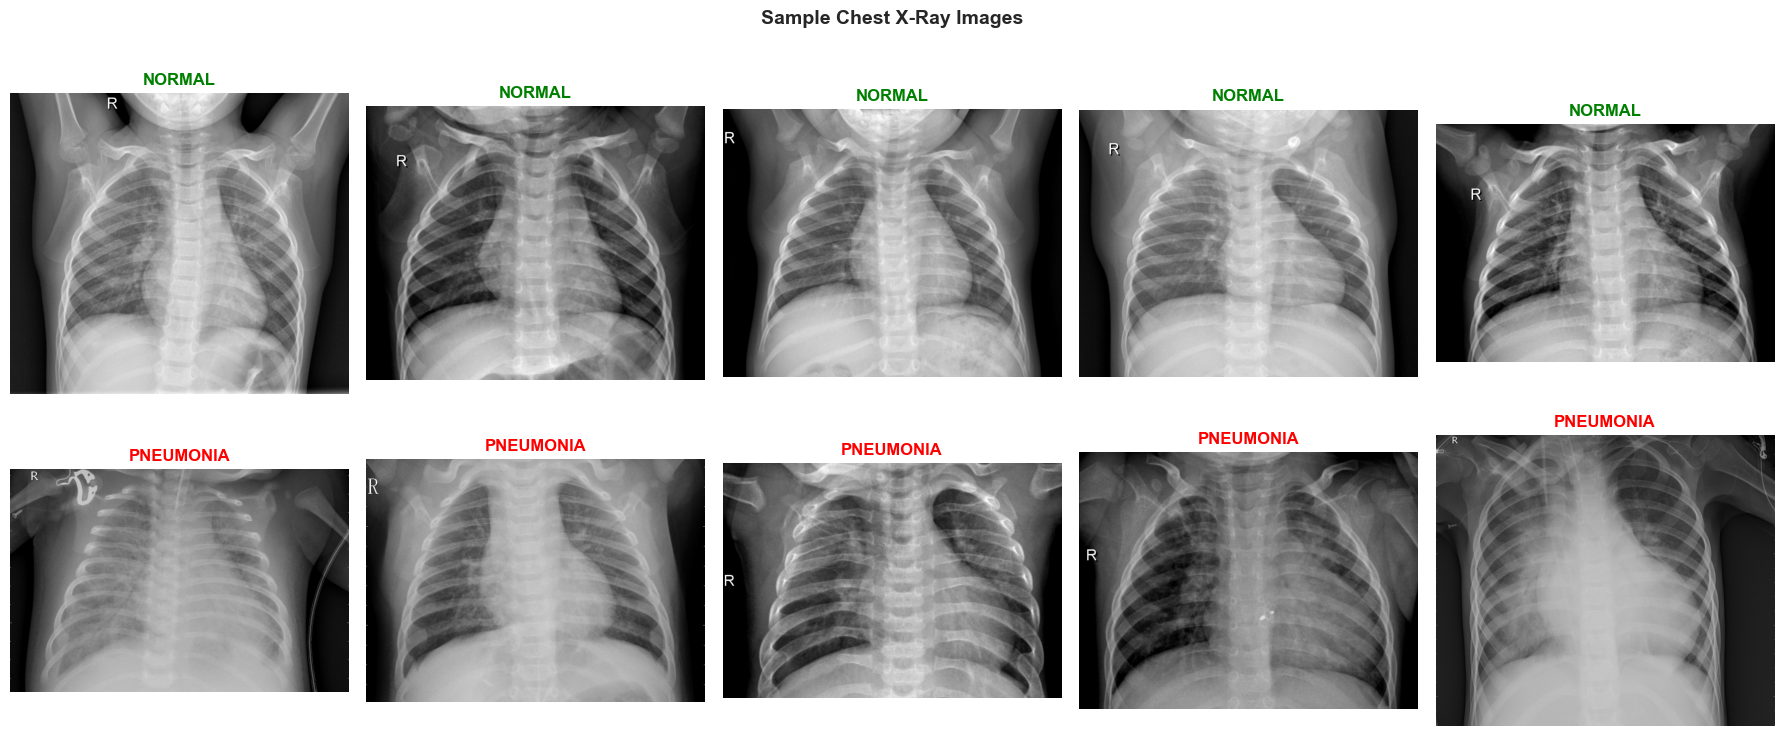

In [5]:
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

# Normal samples
normal_dir = os.path.join(TRAIN_DIR, 'NORMAL')
normal_images = os.listdir(normal_dir)[:5]
for i, img_name in enumerate(normal_images):
    img = Image.open(os.path.join(normal_dir, img_name))
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title('NORMAL', color='green', fontweight='bold')
    axes[0, i].axis('off')

# Pneumonia samples
pneumonia_dir = os.path.join(TRAIN_DIR, 'PNEUMONIA')
pneumonia_images = os.listdir(pneumonia_dir)[:5]
for i, img_name in enumerate(pneumonia_images):
    img = Image.open(os.path.join(pneumonia_dir, img_name))
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title('PNEUMONIA', color='red', fontweight='bold')
    axes[1, i].axis('off')

plt.suptitle('Sample Chest X-Ray Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.3 Image Size Distribution

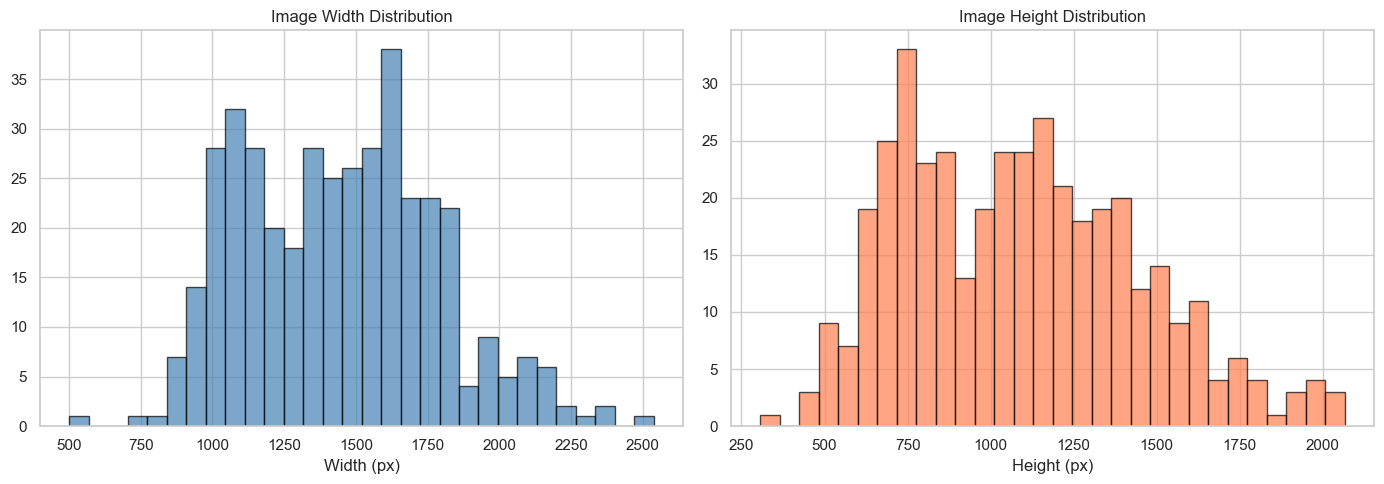

Width  — min: 502, max: 2538, mean: 1442
Height — min: 307, max: 2066, mean: 1086


In [6]:
widths, heights = [], []
for cls in ['NORMAL', 'PNEUMONIA']:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    for img_name in os.listdir(cls_dir)[:200]:  # sample 200 per class
        img = Image.open(os.path.join(cls_dir, img_name))
        w, h = img.size
        widths.append(w)
        heights.append(h)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(widths, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Image Width Distribution')
axes[0].set_xlabel('Width (px)')

axes[1].hist(heights, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Image Height Distribution')
axes[1].set_xlabel('Height (px)')

plt.tight_layout()
plt.show()

print(f'Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}')
print(f'Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}')

### 3.4 Average Pixel Intensity Comparison

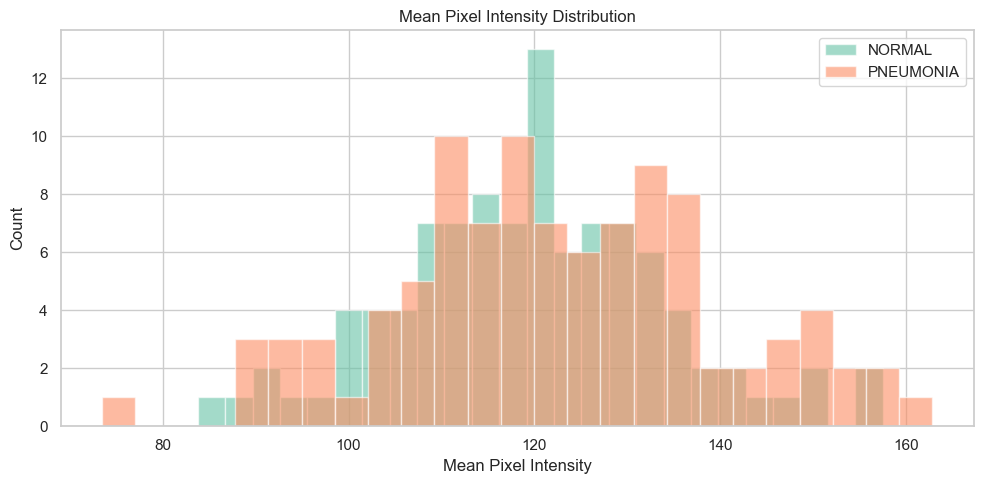

Normal mean intensity:    119.58
Pneumonia mean intensity: 122.32


In [10]:
def get_mean_intensities(class_dir, n_samples=100):
    intensities = []
    for img_name in os.listdir(class_dir)[:n_samples]:
        img = Image.open(os.path.join(class_dir, img_name)).convert('L')
        img_arr = np.array(img.resize((IMG_SIZE, IMG_SIZE)))
        intensities.append(img_arr.mean())
    return intensities

normal_intensities = get_mean_intensities(os.path.join(TRAIN_DIR, 'NORMAL'))
pneumonia_intensities = get_mean_intensities(os.path.join(TRAIN_DIR, 'PNEUMONIA'))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(normal_intensities, bins=25, alpha=0.6, label='NORMAL', color='#66c2a5')
ax.hist(pneumonia_intensities, bins=25, alpha=0.6, label='PNEUMONIA', color='#fc8d62')
ax.set_title('Mean Pixel Intensity Distribution')
ax.set_xlabel('Mean Pixel Intensity')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Normal mean intensity:    {np.mean(normal_intensities):.2f}')
print(f'Pneumonia mean intensity: {np.mean(pneumonia_intensities):.2f}')

---
## 4. Data Preprocessing & Loading

In [12]:
from torch.utils.data import ConcatDataset, random_split

# Stronger augmentation to reduce overfitting
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Merge the tiny original val set into training, then create a proper 85/15 split
full_train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
original_val_dataset = datasets.ImageFolder(VAL_DIR, transform=train_transform)
merged_dataset = ConcatDataset([full_train_dataset, original_val_dataset])

val_size = int(0.15 * len(merged_dataset))
train_size = len(merged_dataset) - val_size
train_dataset, val_dataset = random_split(merged_dataset, [train_size, val_size],
                                          generator=torch.Generator().manual_seed(42))

test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)

class_names = full_train_dataset.classes

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Classes: {class_names}')
print(f'Original train+val merged: {len(merged_dataset)}')
print(f'New Train: {len(train_dataset)} | New Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Classes: ['NORMAL', 'PNEUMONIA']
Original train+val merged: 5232
New Train: 4448 | New Val: 784 | Test: 624


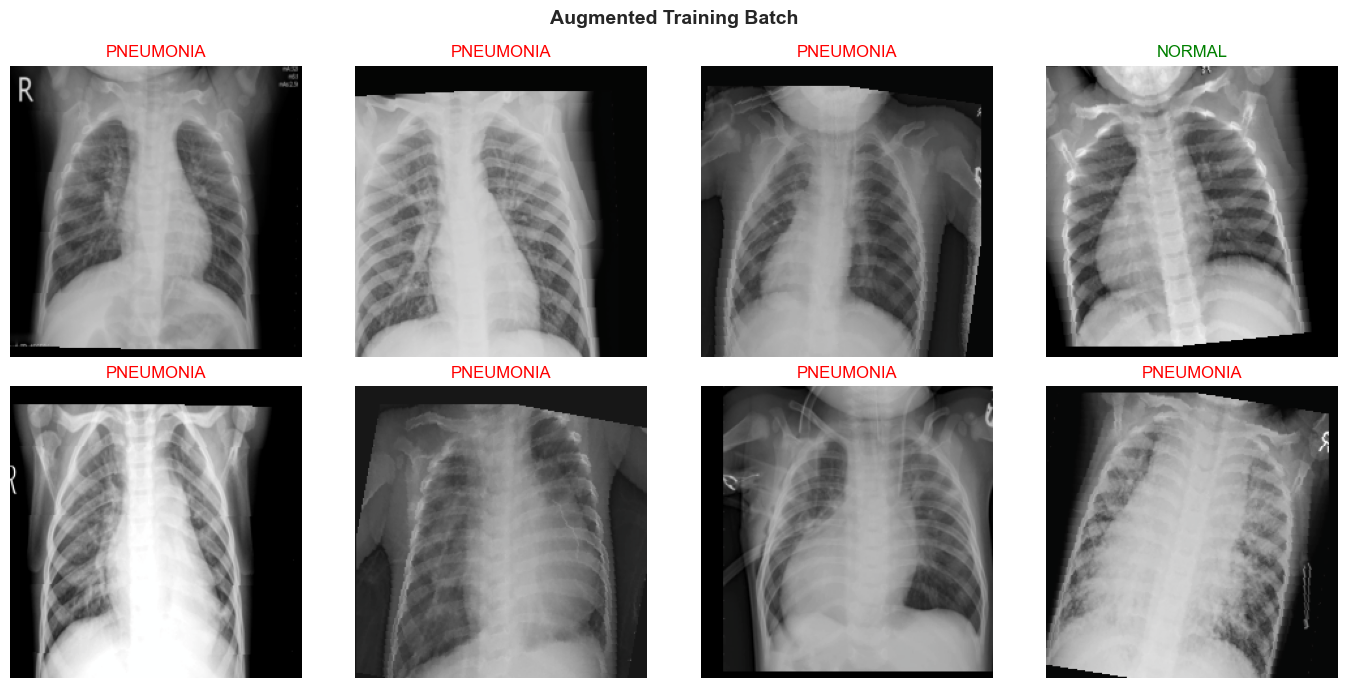

In [13]:
# Visualize a batch of augmented training images
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    img = images[i].permute(1, 2, 0).numpy()
    # Undo normalization for display
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(class_names[labels[i]], color='green' if labels[i] == 0 else 'red')
    ax.axis('off')

plt.suptitle('Augmented Training Batch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Model Training & Comparison

In [15]:
# Model definitions — backbone frozen initially, with dropout to reduce overfitting
def get_resnet50(num_classes=2):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    # Freeze all backbone layers
    for param in model.parameters():
        param.requires_grad = False
    # Replace classifier with dropout + linear
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(2048, num_classes)
    )
    return model

def get_efficientnet_b0(num_classes=2):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    # Freeze all backbone layers
    for param in model.parameters():
        param.requires_grad = False
    # Replace classifier with dropout + linear
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, num_classes)
    )
    return model

def unfreeze_backbone(model):
    """Unfreeze all layers for fine-tuning after initial frozen epochs."""
    for param in model.parameters():
        param.requires_grad = True

In [16]:
# Training function with early stopping, backbone unfreezing, and LR scheduler
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs,
                patience=PATIENCE, freeze_epochs=FREEZE_EPOCHS):
    best_val_loss = float('inf')
    best_val_acc = 0.0
    best_state = None
    epochs_no_improve = 0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    for epoch in range(num_epochs):
        # Unfreeze backbone after freeze_epochs
        if epoch == freeze_epochs:
            print(f'  >>> Unfreezing backbone at epoch {epoch+1}')
            unfreeze_backbone(model)
            # Lower LR for backbone, keep higher for classifier
            optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE * 0.1)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

        # Train phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / total
        epoch_train_acc = correct / total
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)

        # Validation phase
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total
        val_losses.append(epoch_val_loss)
        val_accs.append(epoch_val_acc)

        scheduler.step(epoch_val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        print(f'  Epoch [{epoch+1}/{num_epochs}] '
              f'Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | '
              f'Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f} | '
              f'LR: {current_lr:.1e}')

        # Early stopping on val loss
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_val_acc = epoch_val_acc
            best_state = model.state_dict().copy()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'  >>> Early stopping at epoch {epoch+1} (no val loss improvement for {patience} epochs)')
                break

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    return best_val_acc, train_losses, val_losses, train_accs, val_accs

# Evaluation function
def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [17]:
# Class-weighted loss to handle imbalance
train_targets = [label for _, label in full_train_dataset.samples]
train_counts = [train_targets.count(i) for i in range(len(class_names))]
total_samples = sum(train_counts)
class_weights = torch.FloatTensor([total_samples / c for c in train_counts]).to(DEVICE)
print(f'Class weights: {class_weights}')

# Train all models
model_configs = {
    'ResNet-50': get_resnet50,
    'EfficientNet-B0': get_efficientnet_b0,
}

results = {}
for name, model_fn in model_configs.items():
    print(f'\nTraining {name}...')
    model = model_fn().to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_val_acc, train_losses, val_losses, train_accs, val_accs = train_model(
        model, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS
    )
    results[name] = {
        'best_val_acc': best_val_acc,
        'model': model,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
    }
    print(f'  Best Val Accuracy: {best_val_acc:.4f}')

Class weights: tensor([3.8896, 1.3461])

Training ResNet-50...
  Epoch [1/15] Train Loss: 0.6092 | Train Acc: 0.7945 | Val Loss: 0.5517 | Val Acc: 0.8533 | LR: 1.0e-04
  Epoch [2/15] Train Loss: 0.5054 | Train Acc: 0.8527 | Val Loss: 0.4772 | Val Acc: 0.8495 | LR: 1.0e-04
  Epoch [3/15] Train Loss: 0.4449 | Train Acc: 0.8550 | Val Loss: 0.4182 | Val Acc: 0.8750 | LR: 1.0e-04
  >>> Unfreezing backbone at epoch 4
  Epoch [4/15] Train Loss: 0.3053 | Train Acc: 0.8779 | Val Loss: 0.2314 | Val Acc: 0.8941 | LR: 1.0e-05
  Epoch [5/15] Train Loss: 0.1946 | Train Acc: 0.9249 | Val Loss: 0.1713 | Val Acc: 0.9222 | LR: 1.0e-05
  Epoch [6/15] Train Loss: 0.1452 | Train Acc: 0.9438 | Val Loss: 0.1340 | Val Acc: 0.9413 | LR: 1.0e-05
  Epoch [7/15] Train Loss: 0.1268 | Train Acc: 0.9530 | Val Loss: 0.1316 | Val Acc: 0.9528 | LR: 1.0e-05
  Epoch [8/15] Train Loss: 0.1121 | Train Acc: 0.9584 | Val Loss: 0.1180 | Val Acc: 0.9566 | LR: 1.0e-05
  Epoch [9/15] Train Loss: 0.1105 | Train Acc: 0.9589 | Val 

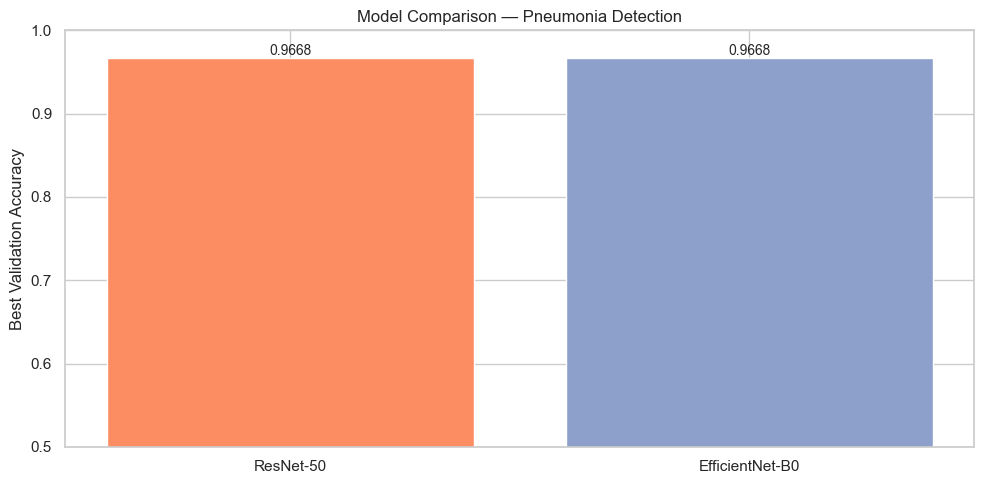

In [18]:
# Model comparison bar chart
model_names = list(results.keys())
val_accs = [results[n]['best_val_acc'] for n in model_names]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(model_names, val_accs, color=['#fc8d62', '#8da0cb'])
ax.set_ylabel('Best Validation Accuracy')
ax.set_title('Model Comparison — Pneumonia Detection')
ax.set_ylim(0.5, 1.0)
ax.bar_label(bars, fmt='%.4f', fontsize=10)
plt.tight_layout()
plt.show()

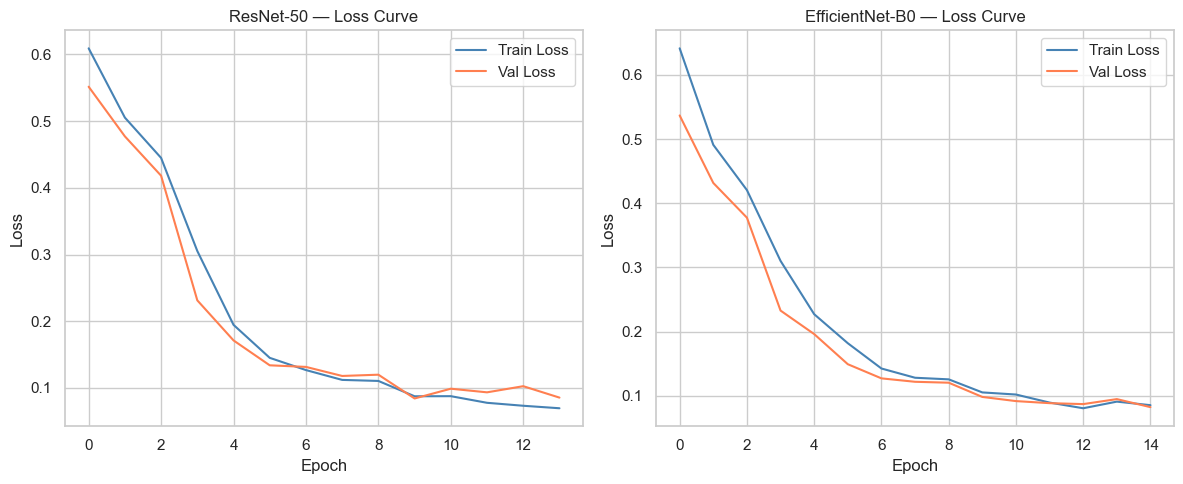

In [19]:
# Training curves for each model
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
if len(results) == 1:
    axes = [axes]

for i, (name, res) in enumerate(results.items()):
    axes[i].plot(res['train_losses'], label='Train Loss', color='steelblue')
    axes[i].plot(res['val_losses'], label='Val Loss', color='coral')
    axes[i].set_title(f'{name} — Loss Curve')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()

plt.tight_layout()
plt.show()

---
## 6. Best Model — Detailed Evaluation

In [20]:
best_name = max(results, key=lambda k: results[k]['best_val_acc'])
best_model = results[best_name]['model']
print(f'Best model: {best_name}')

y_true, y_pred, y_probs = evaluate_model(best_model, test_loader)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_probs)

print(f'\nAccuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')
print(f'ROC-AUC:   {roc_auc:.4f}')
print(f'\nClassification Report:\n{classification_report(y_true, y_pred, target_names=class_names)}')

Best model: ResNet-50

Accuracy:  0.9022
Precision: 0.8730
Recall:    0.9872
F1 Score:  0.9266
ROC-AUC:   0.9731

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.97      0.76      0.85       234
   PNEUMONIA       0.87      0.99      0.93       390

    accuracy                           0.90       624
   macro avg       0.92      0.87      0.89       624
weighted avg       0.91      0.90      0.90       624



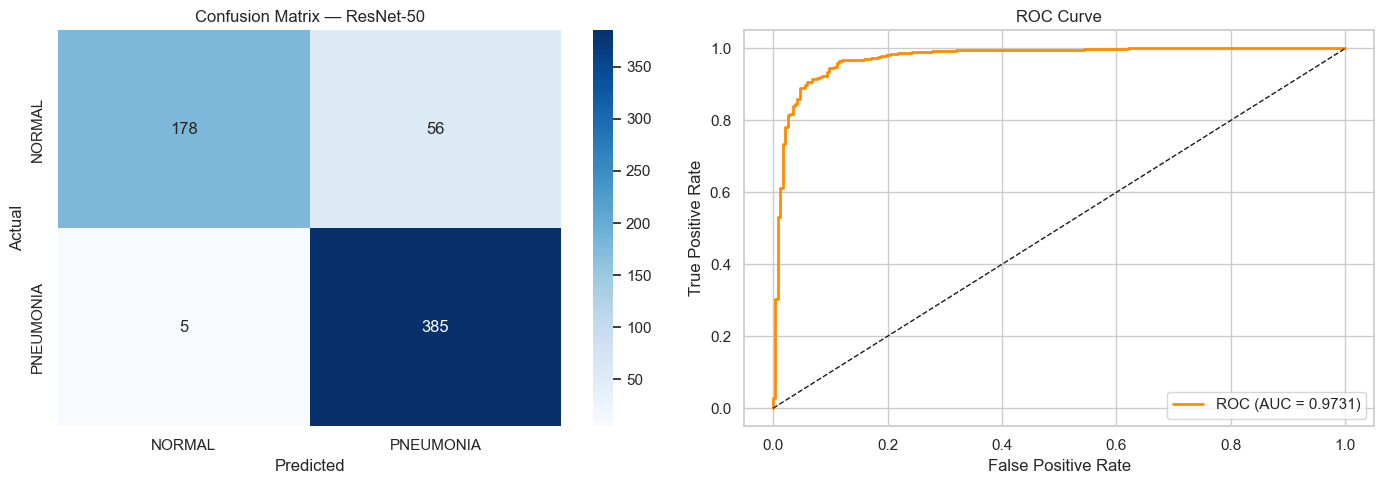

In [21]:
# Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title(f'Confusion Matrix — {best_name}')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_true, y_probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

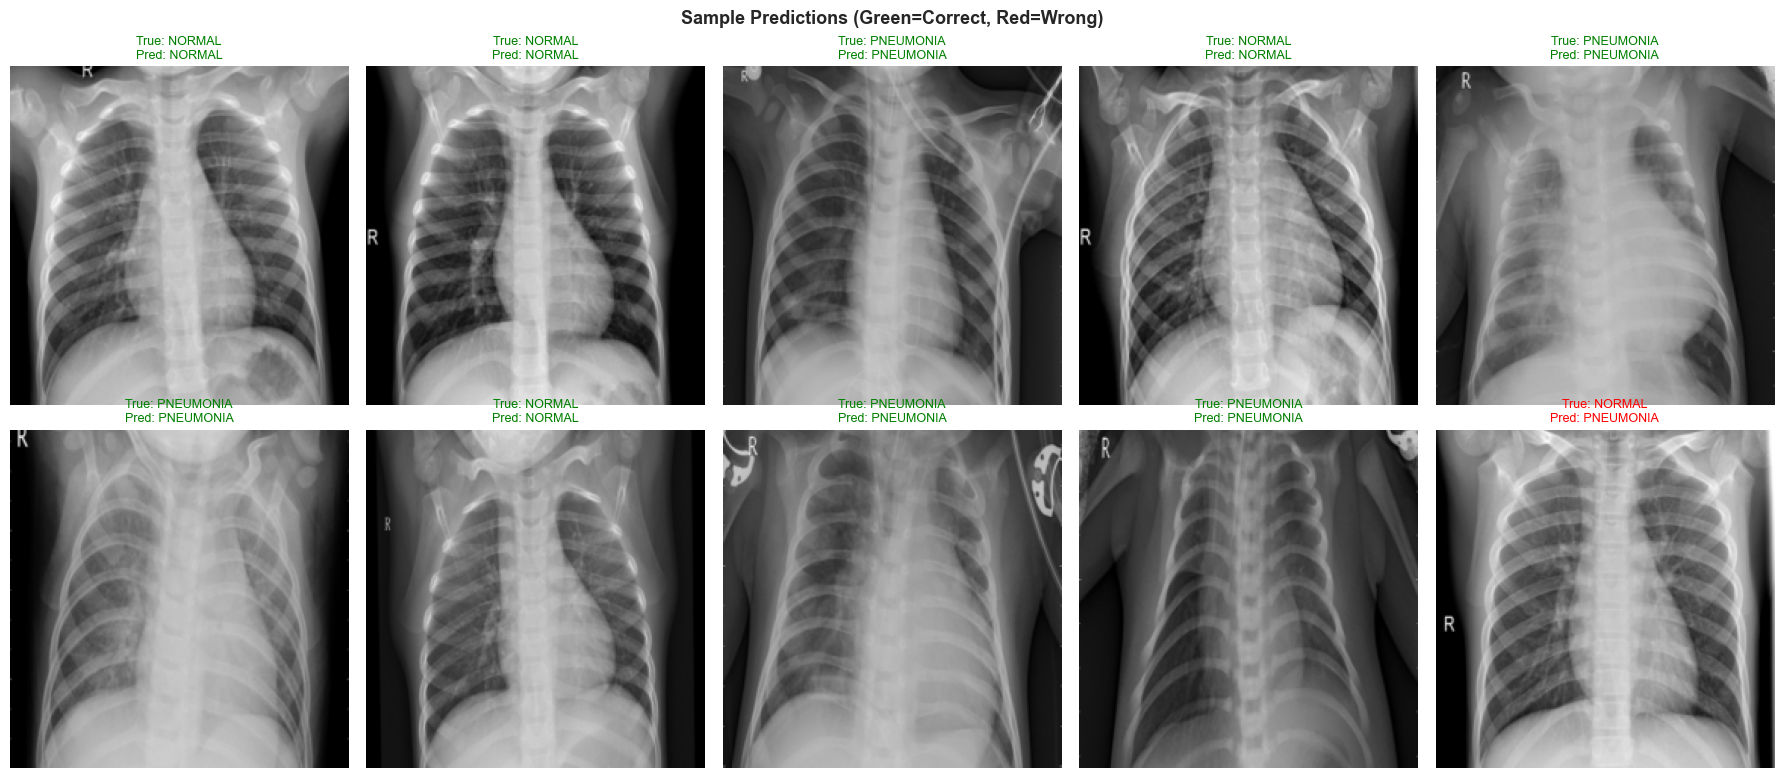

In [23]:
# Sample predictions visualization
test_transform_vis = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
test_dataset_vis = datasets.ImageFolder(TEST_DIR, transform=test_transform_vis)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
indices = np.random.choice(len(test_dataset_vis), 10, replace=False)

for i, idx in enumerate(indices):
    ax = axes[i // 5, i % 5]
    img, true_label = test_dataset_vis[idx]
    pred_label = y_pred[idx]
    ax.imshow(img.permute(1, 2, 0).numpy())
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f'True: {class_names[true_label]}\nPred: {class_names[pred_label]}',
                 color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Save Best Model

In [24]:
model_path = os.path.join(MODELS_DIR, 'pneumonia_model.pth')
torch.save({
    'model_name': best_name,
    'model_state_dict': best_model.state_dict(),
    'class_names': class_names,
    'img_size': IMG_SIZE,
    'accuracy': accuracy,
    'roc_auc': roc_auc,
}, model_path)

print(f'Best model ({best_name}) saved to {model_path}')
print(f'Test Accuracy: {accuracy:.4f} | ROC-AUC: {roc_auc:.4f}')

Best model (ResNet-50) saved to ..\models\pneumonia_model.pth
Test Accuracy: 0.9022 | ROC-AUC: 0.9731
